# Deep Learning Applications: Laboratory #1

In this first laboratory we will work relatively simple architectures to get a feel for working with Deep Models. This notebook is designed to work with PyTorch, but as I said in the introductory lecture: please feel free to use and experiment with whatever tools you like.

**Important Notes**:
1. Be sure to **document** all of your decisions, as well as your intermediate and final results. Make sure your conclusions and analyses are clearly presented. Don't make us dig into your code or walls of printed results to try to draw conclusions from your code.
2. If you use code from someone else (e.g. Github, Stack Overflow, ChatGPT, etc) you **must be transparent about it**. Document your sources and explain how you adapted any partial solutions to creat **your** solution.


### Used tools

In this laboratory I used Copilot inline as support while writing the code and wandb to log and plot the training progresses.


## Exercise 1: Warming Up
In this series of exercises I want you to try to duplicate (on a small scale) the results of the ResNet paper:

> [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385), Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun, CVPR 2016.

We will do this in steps using a Multilayer Perceptron on MNIST.

Recall that the main message of the ResNet paper is that **deeper** networks do not **guarantee** more reduction in training loss (or in validation accuracy). Below you will incrementally build a sequence of experiments to verify this for an MLP. A few guidelines:

+ I have provided some **starter** code at the beginning. **NONE** of this code should survive in your solutions. Not only is it **very** badly written, it is also written in my functional style that also obfuscates what it's doing (in part to **discourage** your reuse!). It's just to get you *started*.
+ These exercises ask you to compare **multiple** training runs, so it is **really** important that you factor this into your **pipeline**. Using [Tensorboard](https://pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) is a **very** good idea -- or, even better [Weights and Biases](https://wandb.ai/site).
+ You may work and submit your solutions in **groups of at most two**. Share your ideas with everyone, but the solutions you submit *must be your own*.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score
import wandb

# seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


Device: cuda


#### Data preparation

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.62MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 247kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


torch.Size([1, 28, 28])
Train: 55000, Val: 5000, Test: 10000


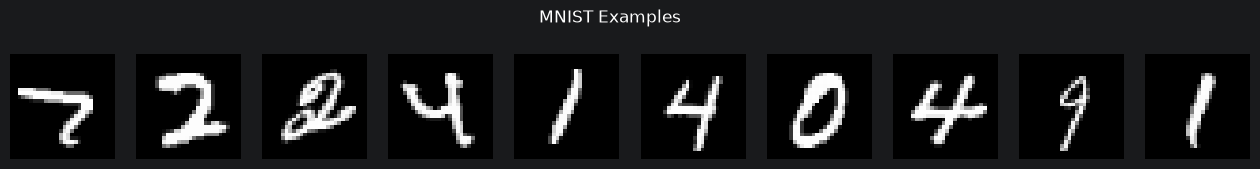

In [3]:
from torchvision.datasets import MNIST

transform_MNIST = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

ds_train = MNIST(root='./data', train=True, download=True, transform=transform_MNIST)
ds_test = MNIST(root='./data', train=False, download=True, transform=transform_MNIST)

# Split train/validation
val_set_size = 5000
perm = np.random.permutation(len(ds_train))
ds_val = Subset(ds_train, perm[:val_set_size])
ds_train = Subset(ds_train, perm[val_set_size:])

img, _ = ds_train[0]
print(img.shape)

print(f'Train: {len(ds_train)}, Val: {len(ds_val)}, Test: {len(ds_test)}')

fig, axes = plt.subplots(1, 10, figsize=(16, 2))

for i in range(10):
    axes[i].imshow(ds_train[i][0].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.suptitle('MNIST Examples')
plt.show()


#### Training e evaluation pipeline

The best way that I found to reuse the code is to make a function that compute just one epoch, then an evaluation function and lastly the `train_model` function, that uses both functions to deploy the training.

In [3]:
def train_one_epoch(model, train_loader, optimizer, criterion, device, epoch):
    model.train()
    running_loss = 0.0
    total = 0

    pbar = tqdm(train_loader, desc=f"Training epoch {epoch}", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Weighted average mean on the batch
        running_loss += loss.item() * labels.size(0)
        total += labels.size(0)
        pbar.set_postfix(loss=loss.item())

    return running_loss / total


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    running_loss = 0.0
    total = 0

    with torch.no_grad(): # deactivate the computational graph
        for inputs, labels in tqdm(loader, desc='Evaluating', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = F.cross_entropy(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return {
        'loss': running_loss / total,
        'accuracy': (all_preds == all_labels).mean(),
        'precision': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='weighted', zero_division=0),
    }


In [4]:
def train_model(model, train_loader, val_loader, epochs, learning_rate, run_name, project="DLA-lab1", config_extra=None, log_wandb=True):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    # Decresing learning rate within T_max epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    if log_wandb:
        config = {"epochs": epochs, "learning_rate": learning_rate}
        if config_extra:
            config.update(config_extra)
        wandb.init(project=project, name=run_name, config=config, reinit=True)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch)
        val_metrics = evaluate(model, val_loader, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])

        if log_wandb:
            wandb.log({
                "epoch": epoch,
                "train/loss": train_loss,
                "val/loss": val_metrics["loss"],
                "val/accuracy": val_metrics["accuracy"],
                "val/f1": val_metrics["f1"],
            })

    if log_wandb:
        wandb.finish()

    print(f"[{run_name}] Val accuracy: {val_metrics['accuracy']:.4f} | Val loss: {val_metrics['loss']:.4f} | F1: {val_metrics['f1']:.4f}")
    return history, val_metrics


### Exercise 1.1: A baseline MLP

Implement a *simple* Multilayer Perceptron to classify the 10 digits of MNIST (e.g. two *narrow* layers). Use my code above as inspiration, but implement your own training pipeline -- you will need it later. Train this model to convergence, monitoring (at least) the loss and accuracy on the training and validation sets for every epoch. Below I include a basic implementation to get you started -- remember that you should write your *own* pipeline!

**Note**: This would be a good time to think about *abstracting* your model definition, and training and evaluation pipelines in order to make it easier to compare performance of different models.

**Important**: Given the *many* runs you will need to do, and the need to *compare* performance between them, this would **also** be a great point to study how **Tensorboard** or **Weights and Biases** can be used for performance monitoring.

In [5]:
class MLP(nn.Module):
    """ MLP without skip connections """
    def __init__(self, input_dim, hidden_dim, output_dim, depth=2, dropout=0.0):
        super().__init__()
        # Projection of the input in the hidden_dim layer
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        for _ in range(depth - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        return self.network(x)


In [6]:
epochs = 20
batch_size = 128
learning_rate = 1e-3
hidden_size = 64
dropout = 0.2

dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=4)
dl_val = DataLoader(ds_val, batch_size=batch_size, num_workers=4)
dl_test = DataLoader(ds_test, batch_size=batch_size, num_workers=4)

baseline_mlp = MLP(input_dim=28*28, hidden_dim=hidden_size, output_dim=10, depth=2, dropout=dropout)

history_baseline, _ = train_model(
    baseline_mlp, dl_train, dl_val, epochs, learning_rate,
    run_name="mlp-baseline",
    config_extra={"hidden_size": hidden_size, "depth": 2, "dropout": dropout}
)
# test
test_metrics_baseline = evaluate(baseline_mlp, dl_test, device)
print(f"Test accuracy baseline MLP: {test_metrics_baseline['accuracy']:.4f}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/SpankyElia/.netrc.
wandb: Currently logged in as: eliamatt (eliamatt-universit-degli-studi-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▄▅▆▇▆▇▇█▇▇█████████
val/f1,▁▄▅▆▇▆▇▇█▇▇█████████
val/loss,█▅▃▃▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁
epoch,20
train/loss,0.07491
val/accuracy,0.9766
val/f1,0.97659
val/loss,0.07812


[mlp-baseline] Val accuracy: 0.9766 | Val loss: 0.0781 | F1: 0.9766


Test accuracy baseline MLP: 0.9773


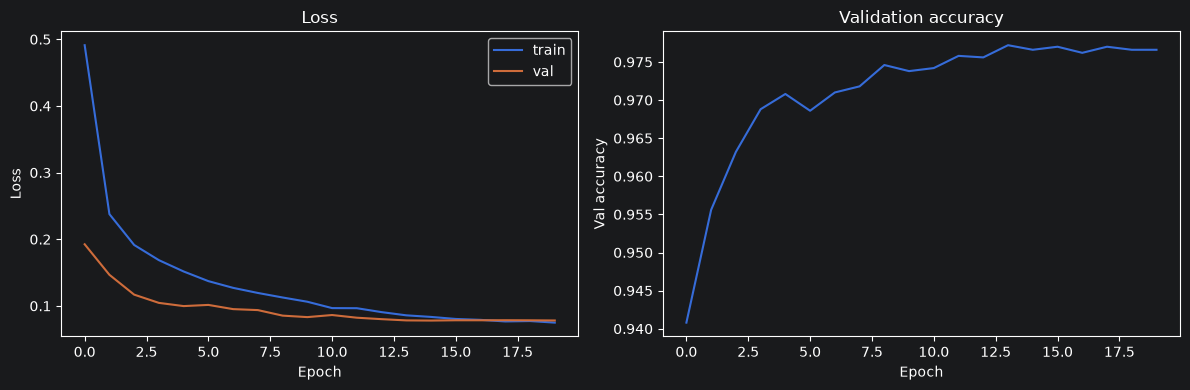

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_baseline['train_loss'], label='train')
axes[0].plot(history_baseline['val_loss'], label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Loss')

axes[1].plot(history_baseline['val_acc'])
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val accuracy'); axes[1].set_title('Validation accuracy')
plt.tight_layout()
plt.show()


**Observations (Exercise 1.1)**:
With MNITS dataset, an easy dataset, a simple MLP with few layers (2 hidden layers + output layer) and 20 epochs can perform really well. There are no big sign of overfitting even though the validation accuracy is not the smoothest.

The model reached validation accuracy of *0.9766* and test accuracy of *0.9773*

### Exercise 1.2: Adding Residual Connections

Implement a variant of your parameterized MLP network to support **residual** connections. Your network should be defined as a composition of **residual MLP** blocks that have one or more linear layers and add a skip connection from the block input to the output of the final linear layer.

**Compare** the performance (in training/validation loss and test accuracy) of your MLP and ResidualMLP for a range of depths. Verify that deeper networks **with** residual connections are easier to train than a network of the same depth **without** residual connections.

**For extra style points**: See if you can explain by analyzing the gradient magnitudes on a single training batch *why* this is the case.

In [8]:
class ResidualBlock(nn.Module):
    """ MLP With residual blocks """
    def __init__(self, dim, n_layers=2, dropout=0.0):
        super().__init__()
        layers = []
        for _ in range(n_layers):
            # dim -> dim for the skip connections
            layers.append(nn.Linear(dim, dim))
            layers.append(nn.ReLU(inplace=True))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        # Skip connection from the input + F(x) to the output of the block
        return x + self.block(x)


class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_blocks=3, layers_per_block=2, dropout=0.0):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        # Depth n_blocks * layers_per_block layers
        self.blocks = nn.Sequential(*[
            ResidualBlock(hidden_dim, n_layers=layers_per_block, dropout=dropout) for _ in range(n_blocks)
        ])
        self.classifier = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.input_layer(x))
        x = self.blocks(x)
        return self.classifier(x)


In [9]:
epochs = 20
batch_size = 128
learning_rate = 1e-3
hidden_size = 64
dropout = 0.2
depths = [2, 4, 8, 12, 16]

dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=4)
dl_val = DataLoader(ds_val, batch_size=batch_size, num_workers=4)
dl_test = DataLoader(ds_test, batch_size=batch_size, num_workers=4)

acc_no_res, acc_with_res = [], []
test_acc_no_res, test_acc_with_res = [], []

for dep in depths:
    print('_' * 40)
    print(f'MLP (no residual), depth={dep}')
    model = MLP(input_dim=28*28, hidden_dim=hidden_size, output_dim=10, depth=dep, dropout=dropout)
    _, metrics = train_model(model, dl_train, dl_val, epochs, learning_rate,
                              run_name=f"mlp-depth-{dep}",
                              config_extra={"hidden_size": hidden_size, "depth": dep})
    acc_no_res.append(metrics['accuracy'])
    test_metrics = evaluate(model, dl_test, device)
    test_acc_no_res.append(test_metrics['accuracy'])
    print(f'Test accuracy (no residual, depth={dep}): {test_metrics["accuracy"]:.4f}')

    print(f'ResidualMLP, depth={dep}')
    # ogni ResidualBlock ha 2 layer lineari, quindi n_blocks = depth // 2
    model_res = ResidualMLP(input_dim=28*28, hidden_dim=hidden_size, output_dim=10,
                             n_blocks=max(1, dep // 2), layers_per_block=2, dropout=dropout)
    _, metrics_res = train_model(model_res, dl_train, dl_val, epochs, learning_rate,
                                  run_name=f"residual-mlp-depth-{dep}",
                                  config_extra={"hidden_size": hidden_size, "depth": dep})
    acc_with_res.append(metrics_res['accuracy'])
    test_metrics_res = evaluate(model_res, dl_test, device)
    test_acc_with_res.append(test_metrics_res['accuracy'])
    print(f'Test accuracy (residual, depth={dep}): {test_metrics_res["accuracy"]:.4f}')

________________________________________
MLP (no residual), depth=2


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▄▅▆▆▇▇▇▇▇██████████
val/f1,▁▄▅▆▆▇▇▇▇▇██████████
val/loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,20
train/loss,0.0807
val/accuracy,0.9778
val/f1,0.97779
val/loss,0.07345


[mlp-depth-2] Val accuracy: 0.9778 | Val loss: 0.0735 | F1: 0.9778


Test accuracy (no residual, depth=2): 0.9761
ResidualMLP, depth=2


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▆▆▇▇▇▇▇▇██████████
val/f1,▁▃▆▆▇▇▇▇▇▇██████████
val/loss,█▅▃▃▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
train/loss,0.01074
val/accuracy,0.9804
val/f1,0.98039
val/loss,0.07128


...

[mlp-depth-16] Val accuracy: 0.7904 | Val loss: 0.5647 | F1: 0.7604


Test accuracy (no residual, depth=16): 0.7877
ResidualMLP, depth=16


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▄▅▆▆▅▆▆▇▇█▇▇███████
val/f1,▁▄▅▆▆▅▆▆▇▇█▇▇███████
val/loss,█▅▃▂▂▃▂▂▁▁▁▁▁▂▁▁▁▁▁▁
epoch,20
train/loss,0.0058
val/accuracy,0.982
val/f1,0.982
val/loss,0.07652


[residual-mlp-depth-16] Val accuracy: 0.9820 | Val loss: 0.0765 | F1: 0.9820


Test accuracy (residual, depth=16): 0.9816


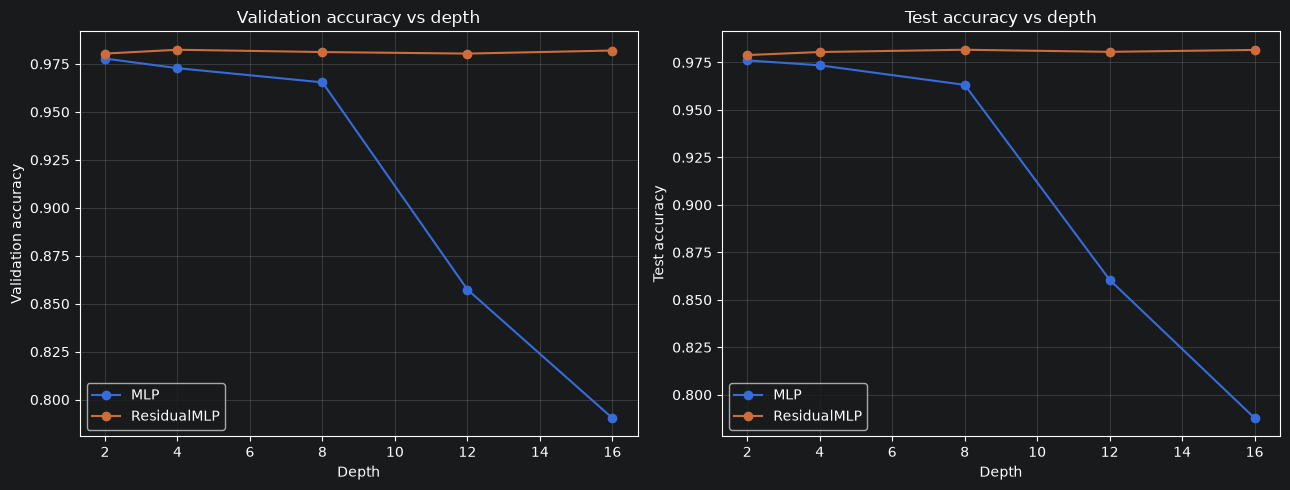

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(depths, acc_no_res, marker='o', label='MLP')
axes[0].plot(depths, acc_with_res, marker='o', label='ResidualMLP')
axes[0].set_xlabel('Depth'); axes[0].set_ylabel('Validation accuracy')
axes[0].set_title('Validation accuracy vs depth'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(depths, test_acc_no_res, marker='o', label='MLP')
axes[1].plot(depths, test_acc_with_res, marker='o', label='ResidualMLP')
axes[1].set_xlabel('Depth'); axes[1].set_ylabel('Test accuracy')
axes[1].set_title('Test accuracy vs depth'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Simple MLP vs MLP with residuals connections
<div style="display: flex; gap: 20px;">
    <img src="./assets/residualsVSnonResiduals.svg" width="49%">
    <img src="./assets/valResidualsVSnonResiduals.svg" width="49%">
</div>
This two graphs, with the two above, shows clearly that going deeper with a simple MLP doesn't give better results, in fact if you look at the higher lines (worst performance) in the graphs are the one with more layer in the simple MLP architecture. Instead the MLP with residuals connections stay near zero all the time even when the model have more and more layers.

### Gradients analysis

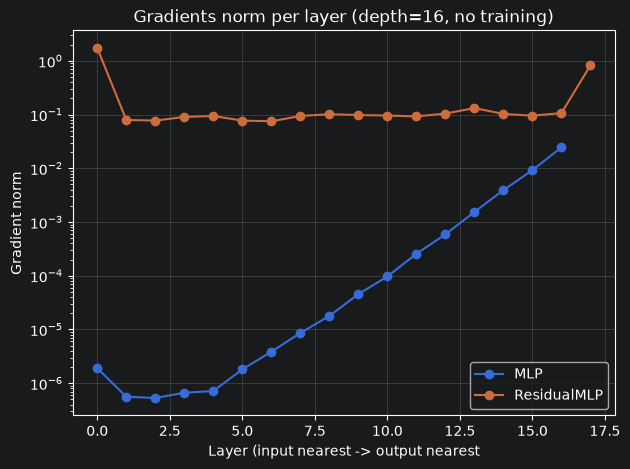

In [11]:
def grad_norms_per_layer(model, x, y):
    # L2 norm of the gradients of the parameters of the model after one forward+backward
    # ona single batch
    model.zero_grad()
    out = model(x)
    loss = F.cross_entropy(out, y)
    loss.backward()
    norms = []
    for name, p in model.named_parameters():
        # Skip the 'bias' terms, evaluate just the 'weight' terms
        if 'weight' in name and p.grad is not None:
            norms.append(p.grad.norm().item())
    return norms

xb, yb = next(iter(dl_train))
xb, yb = xb.to(device), yb.to(device)

deepest = depths[-1]
# dropout=0.0 to not alter the value of the gradiets of the architecture
model_plain = MLP(input_dim=28*28, hidden_dim=hidden_size, output_dim=10, depth=deepest, dropout=0.0).to(device)
model_res = ResidualMLP(input_dim=28*28, hidden_dim=hidden_size, output_dim=10,
                        n_blocks=max(1, deepest // 2), layers_per_block=2, dropout=0.0).to(device)

norms_plain = grad_norms_per_layer(model_plain, xb, yb)
norms_res = grad_norms_per_layer(model_res, xb, yb)

plt.figure(figsize=(7, 5))
plt.plot(norms_plain, marker='o', label='MLP')
plt.plot(norms_res, marker='o', label='ResidualMLP')
plt.xlabel('Layer (input nearest -> output nearest')
plt.ylabel('Gradient norm')
plt.yscale('log')
plt.title(f'Gradients norm per layer (depth={deepest}, no training)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### Observations (Exercise 1.2):

Here we are looking at the gradient norm of the simple MLP and the residual MLP. This is a crystal clear example of *vanishing gradient*, and so the reason why simple MLP without skip connection perform better with less layers. In the meanwhile this phenomenon doesn't affect the MLP version with residuals.

### Exercise 1.3: Rinse and Repeat (but with a CNN)

Repeat the verification you did above, but with **Convolutional** Neural Networks. If you were careful about abstracting your model and training code, this should be a simple exercise. Show that **deeper** CNNs *without* residual connections do not always work better and **even deeper** ones *with* residual connections.

**Hint**: You probably should do this exercise using CIFAR-10, since MNIST is *very* easy (at least up to about 99% accuracy).

**Tip**: Feel free to reuse the ResNet building blocks defined in `torchvision.models.resnet` (e.g. [BasicBlock](https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py#L59) which handles the cascade of 3x3 convolutions, skip connections, and optional downsampling). This is an excellent exercise in code diving.

**Spoiler**: Depending on the optional exercises you plan to do below, you should think *very* carefully about the architectures of your CNNs here (so you can reuse them!).

100%|██████████| 170M/170M [26:51<00:00, 106kB/s]  
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014539152..1.0235696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0026315749..1.027596].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0026315749..1.0252087].


Train: 45000, Val: 5000, Test: 10000


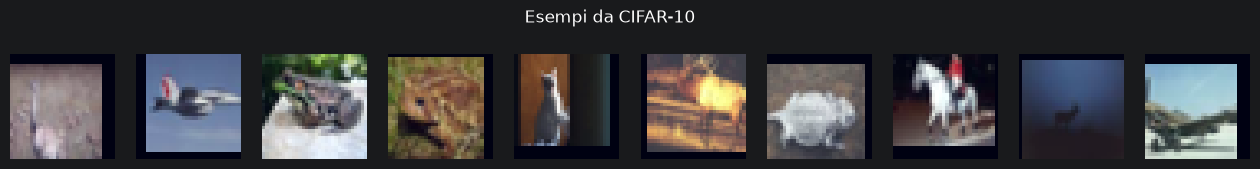

In [12]:
from torchvision.datasets import CIFAR10

transform_CIFAR = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
transform_test_CIFAR = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

ds_train_cnn = CIFAR10(root='./data', train=True, download=True, transform=transform_CIFAR)
ds_eval_cnn = CIFAR10(root='./data', train=True, download=True, transform=transform_test_CIFAR)
ds_test_cnn = CIFAR10(root='./data', train=False, download=True, transform=transform_test_CIFAR)

val_set_size = 5000
perm = np.random.permutation(len(ds_train_cnn))
ds_train_cnn = Subset(ds_train_cnn, perm[val_set_size:])
ds_val_cnn = Subset(ds_eval_cnn, perm[:val_set_size])

print(f'Train: {len(ds_train_cnn)}, Val: {len(ds_val_cnn)}, Test: {len(ds_test_cnn)}')

fig, axes = plt.subplots(1, 10, figsize=(16, 2))
for i in range(10):
    img, label = ds_train_cnn[i]
    axes[i].imshow(img.permute(1, 2, 0) * 0.25 + 0.5)
    axes[i].axis('off')
plt.suptitle('Esempi da CIFAR-10')
plt.show()


In [13]:
from torchvision.models.resnet import BasicBlock

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            # The BatchNorm allow setting bias=False
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SimpleCNN(nn.Module):
    """ Simple CNN with no residual connections """
    def __init__(self, in_channels=3, num_classes=10, width=64, depth=3):
        super().__init__()
        self.stem = ConvBlock(in_channels, width, stride=2)  # 32x32 -> 16x16

        blocks = []
        for i in range(depth - 1):
            stride = 2 if i == 0 else 1  # just another one downsampling 16x16 -> 8x8
            blocks.append(ConvBlock(width, width, stride=stride))
        self.features = nn.Sequential(*blocks)

        # Global Average Pooling reduces every feature map to a scalar value,
        # in this way the number of parameters is reduced, and the network is independent
        # of the spatial size of the input image.
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(width, num_classes)

    def extract_features(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x, 1)

    def forward(self, x):
        return self.classifier(self.extract_features(x))


class ResidualCNN(nn.Module):
    """ Residual CNN with residual connections, same structure of the SimpleCNN but with
     BasicBlock instead of Conv-BatchNorm-ReLU. width is fixed """
    def __init__(self, in_channels=3, num_classes=10, width=64, depth=3):
        super().__init__()
        self.stem = ConvBlock(in_channels, width, stride=2)  # 32x32 -> 16x16

        blocks = []
        for i in range(depth - 1):
            # Same mechanism, just another downsampling
            if i == 0:
                downsample = nn.Sequential(
                    nn.Conv2d(width, width, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(width),
                )
                blocks.append(BasicBlock(width, width, stride=2, downsample=downsample))
            else: #no downsampling
                blocks.append(BasicBlock(width, width, stride=1))
        self.features = nn.Sequential(*blocks)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(width, num_classes)

    def extract_features(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x, 1)

    def forward(self, x):
        return self.classifier(self.extract_features(x))


In [14]:
epochs = 15
batch_size = 128
learning_rate = 1e-3
width = 64
depths_cnn = [2, 8, 14, 20, 32, 44]

dl_train_cnn = DataLoader(ds_train_cnn, batch_size=batch_size, shuffle=True, num_workers=4)
dl_val_cnn = DataLoader(ds_val_cnn, batch_size=batch_size, num_workers=4)
dl_test_cnn = DataLoader(ds_test_cnn, batch_size=batch_size, num_workers=4)

acc_simple_cnn, acc_residual_cnn = [], []
test_acc_simple_cnn, test_acc_residual_cnn = [], []

for dep in depths_cnn:
    print('_' * 60)
    print(f'SimpleCNN, depth={dep}')
    model = SimpleCNN(in_channels=3, num_classes=10, width=width, depth=dep)
    _, metrics = train_model(model, dl_train_cnn, dl_val_cnn, epochs, learning_rate,
                              run_name=f"simplecnn-depth-{dep}",
                              config_extra={"width": width, "depth": dep, "dataset": "CIFAR10"})
    acc_simple_cnn.append(metrics['accuracy'])
    test_metrics = evaluate(model, dl_test_cnn, device)
    test_acc_simple_cnn.append(test_metrics['accuracy'])
    print(f'Test accuracy (SimpleCNN, depth={dep}): {test_metrics["accuracy"]:.4f}')

    print(f'ResidualCNN, depth={dep}')
    model_res = ResidualCNN(in_channels=3, num_classes=10, width=width, depth=dep)
    _, metrics_res = train_model(model_res, dl_train_cnn, dl_val_cnn, epochs, learning_rate,
                                  run_name=f"residualcnn-depth-{dep}",
                                  config_extra={"width": width, "depth": dep, "dataset": "CIFAR10"})
    acc_residual_cnn.append(metrics_res['accuracy'])
    test_metrics_res = evaluate(model_res, dl_test_cnn, device)
    test_acc_residual_cnn.append(test_metrics_res['accuracy'])
    print(f'Test accuracy (ResidualCNN, depth={dep}): {test_metrics_res["accuracy"]:.4f}')


____________________________________________________________
SimpleCNN, depth=2


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train/loss,█▅▄▄▃▃▂▂▂▁▁▁▁▁▁
val/accuracy,▁▃▅▅▅▆▆▇▇▇▇████
val/f1,▁▄▅▅▅▆▆▇▇▇▇████
val/loss,█▆▄▅▄▃▃▃▂▁▂▁▁▁▁
epoch,15
train/loss,1.26319
val/accuracy,0.5584
val/f1,0.55571
val/loss,1.26113


[simplecnn-depth-2] Val accuracy: 0.5584 | Val loss: 1.2611 | F1: 0.5557


Test accuracy (SimpleCNN, depth=2): 0.5524
ResidualCNN, depth=2


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train/loss,█▅▄▄▃▃▂▂▂▂▁▁▁▁▁
val/accuracy,▁▃▂▄▅▅▅▆▇▇▇▇███
val/f1,▁▃▃▄▅▅▅▆▇▇▇████
val/loss,█▆▆▅▄▄▅▃▂▂▁▁▁▁▁
epoch,15
train/loss,0.91213
val/accuracy,0.6732
val/f1,0.67118
val/loss,0.94049


...

[simplecnn-depth-44] Val accuracy: 0.7362 | Val loss: 0.7780 | F1: 0.7354


Test accuracy (SimpleCNN, depth=44): 0.7347
ResidualCNN, depth=44


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train/loss,█▆▅▄▃▃▃▂▂▂▂▁▁▁▁
val/accuracy,▁▂▃▅▅▅▅▇▇▇█████
val/f1,▁▂▃▅▅▅▆▇▇▇█████
val/loss,█▇▆▅▄▄▄▂▂▂▁▁▁▁▁
epoch,15
train/loss,0.35237
val/accuracy,0.843
val/f1,0.84241
val/loss,0.48708


[residualcnn-depth-44] Val accuracy: 0.8430 | Val loss: 0.4871 | F1: 0.8424


Test accuracy (ResidualCNN, depth=44): 0.8404


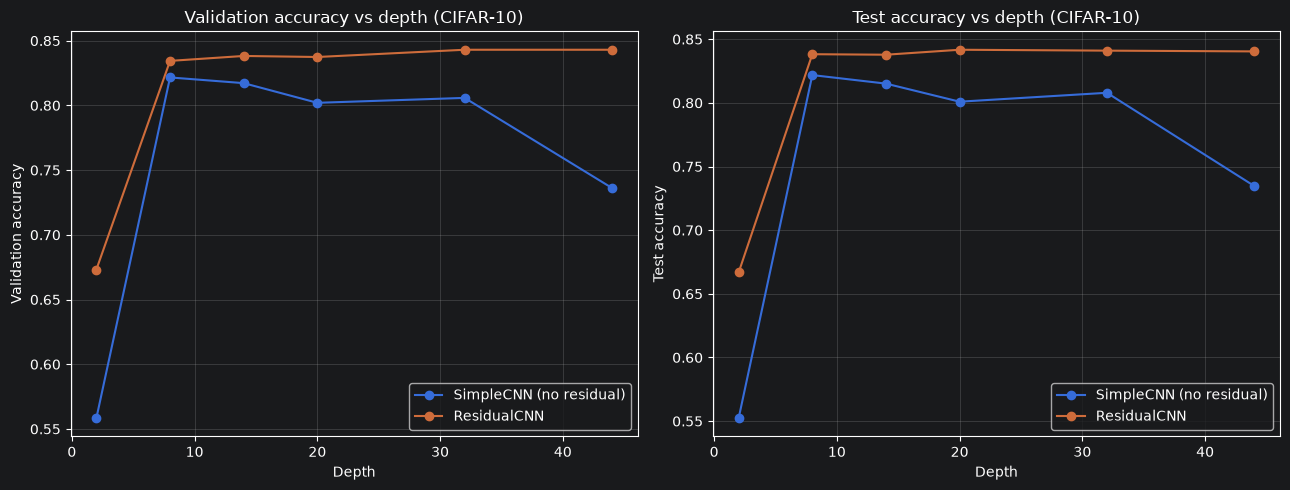

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(depths_cnn, acc_simple_cnn, marker='o', label='SimpleCNN (no residual)')
axes[0].plot(depths_cnn, acc_residual_cnn, marker='o', label='ResidualCNN')
axes[0].set_xlabel('Depth'); axes[0].set_ylabel('Validation accuracy')
axes[0].set_title("Validation accuracy vs depth (CIFAR-10)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(depths_cnn, test_acc_simple_cnn, marker='o', label='SimpleCNN (no residual)')
axes[1].plot(depths_cnn, test_acc_residual_cnn, marker='o', label='ResidualCNN')
axes[1].set_xlabel('Depth'); axes[1].set_ylabel('Test accuracy')
axes[1].set_title("Test accuracy vs depth (CIFAR-10)"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### Observations (Exercise 1.3):
Here another example that going deeper is not always the best solution, in fact the simple CNN with more layers (`depth=32` and `depth=44`) perform worse than the one with fewer layers (`depth=8`). Instead, the residual CNN with more layers perform a little bit better but after `depth=20` this effect vanish and the performance is stable.

In [16]:
# Saving the model to reuse it after
# This is NOT the real best model, is just the last model, but for this specific
# scenario/case are the same (looking at the graph above)
best_cnn = model_res
torch.save(best_cnn.state_dict(), 'residual_cnn_best.pt')


-----
## Exercise 2: Choose at Least One

Below are **three** exercises that ask you to deepen your understanding of Deep Networks for visual recognition. You must choose **at least one** of the below for your final submission -- feel free to do **more**, but at least **ONE** you must submit. Each exercise is designed to require you to dig your hands **deep** into the guts of your models in order to do new and interesting things.

**Note**: These exercises are designed to use your small, custom CNNs and small datasets. This is to keep training times reasonable. If you have a decent GPU, feel free to use pretrained ResNets and larger datasets (e.g. the [Imagenette](https://pytorch.org/vision/0.20/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette) dataset at 160px).

### Exercise 2.1: *Fine-tune* a pre-trained model
Train one of your residual CNN models from Exercise 1.3 on CIFAR-10. Then:
1. Use the pre-trained model as a **feature extractor** (i.e. to extract the feature activations of the layer input into the classifier) on CIFAR-100. Use a **classical** approach (e.g. Linear SVM, K-Nearest Neighbor, or Bayesian Generative Classifier) from scikit-learn to establish a **stable baseline** performance on CIFAR-100 using the features extracted using your CNN.
2. Fine-tune your CNN on the CIFAR-100 training set and compare with your stable baseline. Experiment with different strategies:
    - Unfreeze some of the earlier layers for fine-tuning.
    - Test different optimizers (Adam, SGD, etc.).

Each of these steps will require you to modify your model definition in some way. For 1, you will need to return the activations of the last fully-connected layer (or the global average pooling layer). For 2, you will need to replace the original, 10-class classifier with a new, randomly-initialized 100-class classifier.

### Exercise 2.2: *Distill* the knowledge from a large model into a smaller one
In this exercise you will see if you can derive a *small* model that performs comparably to a larger one on CIFAR-10. To do this, you will use [Knowledge Distillation](https://arxiv.org/abs/1503.02531):

> Geoffrey Hinton, Oriol Vinyals, and Jeff Dean. Distilling the Knowledge in a Neural Network, NeurIPS 2015.

To do this:
1. Train one of your best-performing CNNs on CIFAR-10 from Exercise 1.3 above. This will be your **teacher** model.
2. Define a *smaller* variant with about half the number of parameters (change the width and/or depth of the network). Train it on CIFAR-10 and verify that it performs *worse* than your **teacher**. This small network will be your **student** model.
3. Train the **student** using a combination of **hard labels** from the CIFAR-10 training set (cross entropy loss) and **soft labels** from predictions of the **teacher** (Kulback-Leibler loss between teacher and student).

Try to optimize training parameters in order to maximize the performance of the student. It should at least outperform the student trained only on hard labels in Setp 2.

**Tip**: You can save the predictions of the trained teacher network on the training set and adapt your dataloader to provide them together with hard labels. This will **greatly** speed up training compared to performing a forward pass through the teacher for each batch of training.

### Exercise 2.3: *Explain* the predictions of a CNN

Use the CNN model you trained in Exercise 1.3 and implement [*Class Activation Maps*](http://cnnlocalization.csail.mit.edu/#:~:text=A%20class%20activation%20map%20for,decision%20made%20by%20the%20CNN.):

> B. Zhou, A. Khosla, A. Lapedriza, A. Oliva, and A. Torralba. Learning Deep Features for Discriminative Localization. CVPR'16 (arXiv:1512.04150, 2015).

Use your CNN implementation to demonstrate how your trained CNN *attends* to specific image features to recognize *specific* classes. Try your implementation out using a pre-trained ResNet-18 model and some images from the [Imagenette](https://pytorch.org/vision/0.20/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette) dataset -- I suggest you start with the low resolution version of images at 160px.

**CAM idea**: the activation map for a class is obtained by taking a weighted sum of the feature maps of the last convolutional layer (before global average pooling), using as weights the weights of the final classifier corresponding to that class. Where the map has high values, the network "looks" to decide that class.

In [17]:
# Help from Claude for this part.
def get_cam(model, feature_layer, fc_layer, img_tensor, class_idx=None, device='cpu'):
    """
    feature_layer: layer which the output is the last convolution feature map
    fc_layer: last layer (classifier)
    img_tensor: normalized image
    class_idx: class to be explained
    """
    model.eval().to(device)
    activations = {}

    def hook_fn(module, inp, out):
        activations['fmap'] = out.detach()

    # Forward hook: catch the output of feature_layer during the forward pass without changing the forward() method,
    # intercept the intermediate output layer, not the final output
    handle = feature_layer.register_forward_hook(hook_fn)
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
    handle.remove() # remove hook

    if class_idx is None:
        class_idx = logits.argmax(dim=1).item()

    fmap = activations['fmap'].squeeze(0).cpu()          # (C channels, h height, w width)
    weights = fc_layer.weight[class_idx].detach().cpu()  # final weights relative to the class to explain

    C, h, w = fmap.shape
    cam = torch.zeros(h, w)
    for c in range(C):
        # Weighted sum with weight = importance of the channel given by the final classifier for the class class_idx
        cam += weights[c] * fmap[c]

    # The ReLU allow keeping only the positive value to the chosen class
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8) # 0 - 1 values

    # back to original dimension
    cam = F.interpolate(cam[None, None], size=img_tensor.shape[-2:], mode='bilinear', align_corners=False)
    return cam.squeeze().numpy(), class_idx


def denormalize(img, mean, std):
    # Denormalize the normalization applied on dataset import, in this way colors are correct
    img = img.clone()
    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]
    return img


def show_cam_on_image(img_tensor, cam, mean, std, title=None, ax=None):
    img = denormalize(img_tensor, mean, std).permute(1, 2, 0).clamp(0, 1).numpy()
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(img)
    ax.imshow(cam, cmap='jet', alpha=0.4)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=10)

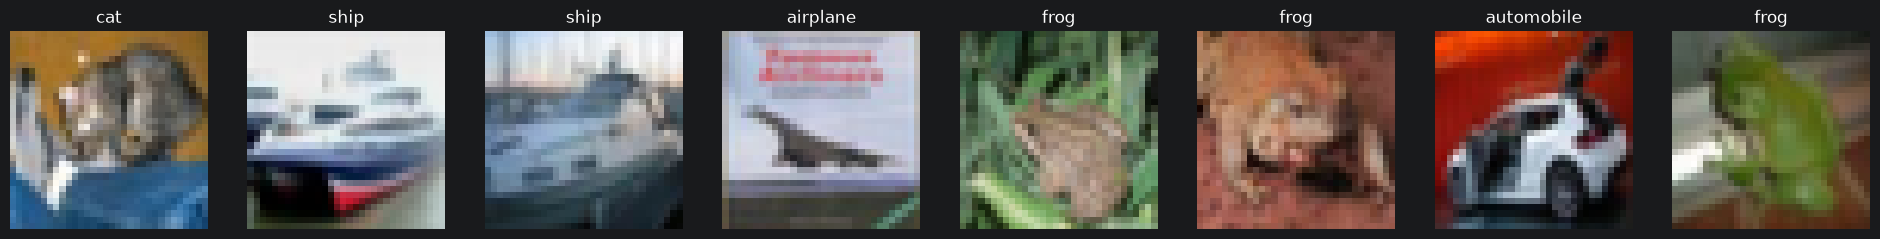

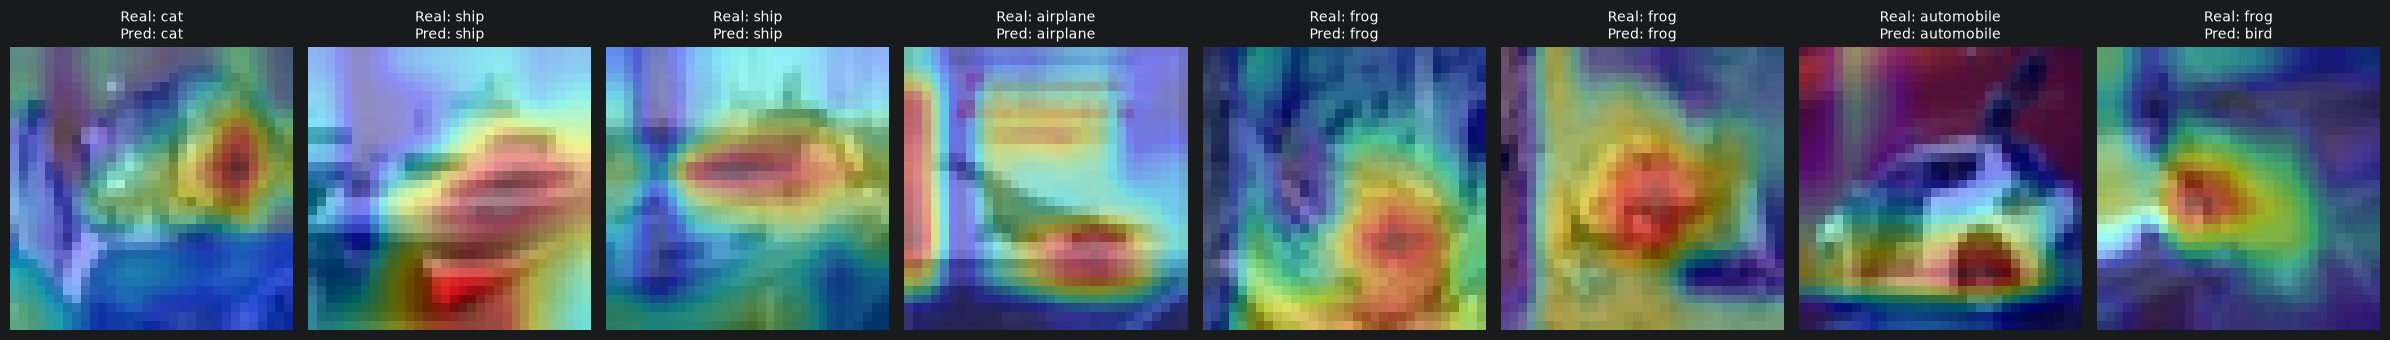

In [18]:
cifar_mean, cifar_std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
cifar_classes = ds_test_cnn.classes

n_examples = 8
fig, axes = plt.subplots(1, n_examples, figsize=(3 * n_examples, 3.5))
for i in range(n_examples):
    img, label = ds_test_cnn[i]
    img_denorm = denormalize(img, cifar_mean, cifar_std).clamp(0, 1)
    axes[i].imshow(img_denorm.permute(1, 2, 0))
    axes[i].axis('off')
    axes[i].set_title(cifar_classes[label])

fig, axes = plt.subplots(1, n_examples, figsize=(3 * n_examples, 3.5))
for i in range(n_examples):
    img, label = ds_test_cnn[i]
    cam, pred_class = get_cam(best_cnn, best_cnn.features, best_cnn.classifier, img, device=device)
    show_cam_on_image(
        img, cam, mean=cifar_mean, std=cifar_std,
        title=f"Real: {cifar_classes[label]}\nPred: {cifar_classes[pred_class]}",
        ax=axes[i]
    )
plt.tight_layout()
plt.show()

100%|██████████| 99.0M/99.0M [00:24<00:00, 4.01MB/s]


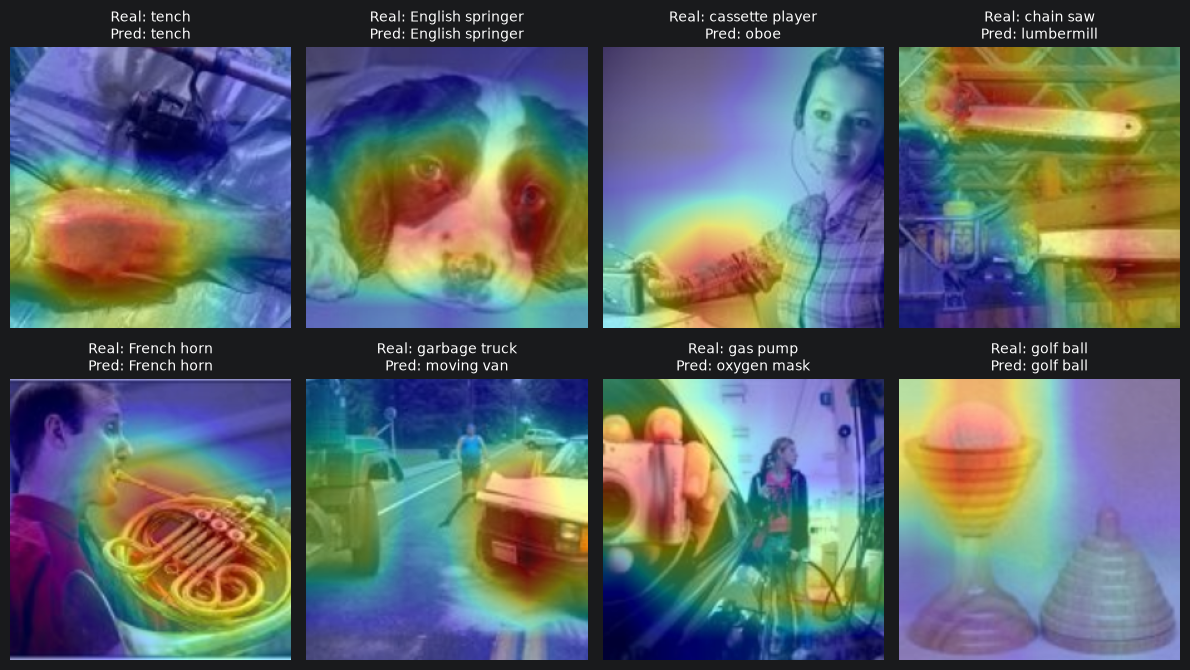

In [19]:
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import Imagenette

weights = ResNet18_Weights.IMAGENET1K_V1
resnet = resnet18(weights=weights).to(device)
imagenet_classes = weights.meta["categories"]
preprocess = weights.transforms()

ds_imagenette = Imagenette(root='./data', split='val', size='160px', download=True, transform=preprocess)

imagenet_mean, imagenet_std = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

n_examples = 8
step = len(ds_imagenette) // n_examples
fig, axes = plt.subplots(2, n_examples // 2, figsize=(3 * (n_examples // 2), 7))
axes = axes.flatten()
for i in range(n_examples):
    img, label = ds_imagenette[i * step]
    cam, pred_class = get_cam(resnet, resnet.layer4, resnet.fc, img, device=device)
    show_cam_on_image(
        img, cam, mean=imagenet_mean, std=imagenet_std,
        title=f"Real: {ds_imagenette.classes[label][0]}\nPred: {imagenet_classes[pred_class]}",
        ax=axes[i]
    )
plt.tight_layout()
plt.show()


#### Observations (Exercise 2.3):
Both models perform pretty well in localizing the object of interest in the image. The CAMs generated by the pre-trained model highlight the relevant regions of the image more decisively. In contrast, the ResidualCNN's CAMs are less focused and may highlight irrelevant areas even though it seems to perform better, suggesting that it has not learned as strong feature representations, probably due to limited training data and model capacity. On the same wave length, the pre-trained model, sometimes misclassifies the objects, but the highlighted regions still seems relevant to the predicted class, and that's the goal: highlights the relevant prediction regions even if the prediction is wrong, we don't have to do better we just have to explain.

**P.S. I don't wanna know what type of cat is the first one.**

## Final Conclusions

This laboratory has shown that depth alone does not guarantee better optimization, and that residual connections are what makes the difference and depth actually usable. The evidence gathered across Exercises 1.1–1.3 is crystal clear. On MNIST, a shallow MLP already does a very good job with accuracy (97.7% test), as plain MLP depth increases, validation and test accuracy degrade, while the ResidualMLP stays flat and high across the same depth range. The gradient-norm analysis in Exercise 1.2 gives the explanation for this phenomenon, the plain network's early layers receive gradients that vanish incredibly fast with the depth increasing, while the residual network's skip connections reamin stable. The same pattern reappears on CIFAR-10 with real convolutional stacks in Exercise 1.3, at much greater depth (up to 44 layers): the plain SimpleCNN peaks around depth 8 and degrades sharply afterward, while ResidualCNN keeps improving up to roughly depth 20 before plateauing, never degrading.

The Exercise 2.3 CAM analysis allow to change prospective, stop looking at the accuracy and the performance of the model but take a look at the model quality: the custom ResidualCNN, despite reasonable accuracy, produces less spatially-focused (but it does a very good job indeed) activation maps than a large ImageNet-pretrained ResNet-18, suggesting its learned features are predictive but not as disentangled — a reminder that test accuracy alone does not certify why a model is right.

Overall, this lab confirms that (1) depth without residual connections is a disadvantages and just costs more, (2) the benefit of residual connections is best explained through gradient flow rather than raw capacity (I never thought of looking directly the gradients, so very useful), and (3) explainability tools like CAM surface failure modes that accuracy metrics alone cannot.